In [5]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td

import gplugins as gp
import gplugins.tidy3d as gt
from gplugins import plot
from gplugins.common.config import PATH

import gplugins.tidy3d.materials as mat
import gdsfactory as gf
import jax
import jax.example_libraries.optimizers as opt
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm

import numpy as np
import sax
from gdsfactory.generic_tech import get_generic_pdk
from scipy import constants
from scipy.constants import c
from scipy.interpolate import interp1d

import gplugins.sax as gs
from gplugins.common.config import PATH

nm = 1e-3
wavelength = np.linspace(1500, 1600) * nm
f = td.C_0 / wavelength

C:\Users\cfp\AppData\Local\Temp\ipykernel_2360\4146502802.py:21: DeprecationWarning: The 'gdsfactory.generic_tech' module is deprecated and will be removed in a future version. Please update your imports to use 'gdsfactory.gpdk' instead:
  from gdsfactory.gpdk import LAYER, LAYER_STACK, get_generic_pdk
Or for submodules:
  from gdsfactory.gpdk.layer_map import LAYER
  from gdsfactory.gpdk.layer_stack import LAYER_STACK
  from gdsfactory.generic_tech import get_generic_pdk


In [6]:
nitride_complex = td.material_library["Si3N4"]["Luke2015PMLStable"].eps_model(f)
nitride_index, nitride_k = td.Medium.eps_complex_to_nk(nitride_complex)
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)

## 1. Simulating Propagation Modes in SOI Waveguides

In [10]:
# STUDENT! Put your code here.
wavelength = np.linspace(1500,1600,6) * nm  # Student code here. Tip np.linspace()
central = 1550*nm

deep_waveguide = gt.modes.Waveguide(
    wavelength=wavelength, 
    core_width=450 * nm, 
    slab_thickness=0.0,
    core_material='si',
    clad_material='sio2',
    core_thickness=220 * nm,
    num_modes=8,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=20, 
)

res_neff = deep_waveguide.n_eff # In this case, the result is not just a number, is a wavelength-dependent vector
res_te = deep_waveguide.fraction_te # Wavelength-dependent vector
res_tm =deep_waveguide.fraction_tm # Wavelength-dependent vector
neff_TE0 = res_neff[:,0].real

coef_TE = np.polyfit(wavelength - central,neff_TE0,2)

n1_TE = coef_TE[2]
n2_TE = coef_TE[1]
n3_TE = coef_TE[0]

ng_TE = n1_TE - central*n2_TE
neff_TM0 = res_neff[:,1].real

coef_TM = np.polyfit(wavelength- central,neff_TM0,2)

n1_TM = coef_TM[2]
n2_TM = coef_TM[1]
n3_TM = coef_TM[0]

ng_TM = n1_TM - central*n2_TM
print(
    f"""
TE0 effective index varies from {neff_TE0[0]:.3f} to {neff_TE0[-1]:.3f}
TM0 effective index varies from {neff_TM0[0]:.3f} to {neff_TM0[-1]:.3f}

ng_TE = {ng_TE:.3f}
ng_TM = {ng_TM:.3f}
"""
)

2026-03-30 09:15:28.447 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_e0ec38b5ceb294b8.npz.

TE0 effective index varies from 2.399 to 2.273
TM0 effective index varies from 1.806 to 1.688

ng_TE = 4.287
ng_TM = 3.571



## 2. Designing Directional Couplers

Primero para un rango de valores de gap y otro de L, calculamos los valores de acoplo y luego de la matriz resultante filtramos los valores de acoplo que necesitamos para ver con que valores de gap y de L se consiguen.

In [15]:
lambda_c = 1.55  # wavelength (um)

gap = np.linspace(0.15, 0.8, 10)  # gap sweep (um)

K_vals = []
Lpi = []

for g in gap:

    dcoupler_cs = gt.modes.WaveguideCoupler(
        # Geometrical Parameters
        core_width=(1.2, 1.2),      # waveguide widths
        slab_thickness=0 * nm,
        core_thickness=300 * nm,
        gap=g,                      # swept parameter
        # Materials
        core_material="si",
        clad_material="sio2",
        # Modesolver Parameters
        wavelength=lambda_c,
        num_modes=5,
        cache_path=".cache/",
        precision="double",
        max_grid_scaling=1.5,
        grid_resolution=20,
    )

    # calcular los modos
    modes = dcoupler_cs.n_eff

   # índices efectivos de los dos supermodos
    neff_even = modes[0].real
    neff_odd = modes[1].real

    # longitud de acoplo π
    L_pi = lambda_c / (2 * (neff_even - neff_odd))
    Lpi.append(L_pi)


Lpi = np.array(Lpi)

# barrido de longitud del acoplador
L = np.linspace(0, 300, 450)

for L_pi in Lpi:
    K = np.sin(np.pi / 2 * (L / L_pi)) ** 2
    K_vals.append(K)

K_vals = np.array(K_vals)

c:\Users\cfp\Desktop\diseño\pic-upv-lab5-finalproject\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
c:\Users\cfp\Desktop\diseño\pic-upv-lab5-finalproject\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
c:\Users\cfp\Desktop\diseño\pic-upv-lab5-finalproject\.ve

09:20:23 Hora de verano romance WARNING: The group index was not computed. To   
                                calculate group index, pass 'group_index_step = 
                                True' in the 'ModeSpec'.                        

2026-03-30 09:20:23.089 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache\WaveguideCoupler_5d74b62dbe38d6be.npz.


c:\Users\cfp\Desktop\diseño\pic-upv-lab5-finalproject\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
c:\Users\cfp\Desktop\diseño\pic-upv-lab5-finalproject\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
c:\Users\cfp\Desktop\diseño\pic-upv-lab5-finalproject\.ve

2026-03-30 09:20:25.709 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache\WaveguideCoupler_8376e98b9ee095a1.npz.


...

2026-03-30 09:20:38.772 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache\WaveguideCoupler_4695c516b16e3a93.npz.


c:\Users\cfp\Desktop\diseño\pic-upv-lab5-finalproject\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
c:\Users\cfp\Desktop\diseño\pic-upv-lab5-finalproject\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
c:\Users\cfp\Desktop\diseño\pic-upv-lab5-finalproject\.ve

2026-03-30 09:20:41.541 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache\WaveguideCoupler_f8c58e67bea3b751.npz.


c:\Users\cfp\Desktop\diseño\pic-upv-lab5-finalproject\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
c:\Users\cfp\Desktop\diseño\pic-upv-lab5-finalproject\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
c:\Users\cfp\Desktop\diseño\pic-upv-lab5-finalproject\.ve

2026-03-30 09:20:44.160 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache\WaveguideCoupler_0601d85da32a9c4d.npz.
2026-03-30 09:20:44.175 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_4cba9ac6f6775c09.npz.


In [16]:
k_objetivos = [0.5, 0.3, 0.23, 0.17, 0.05]

gap_target = 0.15
i = np.argmin(np.abs(gap - gap_target))

for k in k_objetivos:

    diff = np.abs(K_vals[i] - k)
    j = np.argmin(diff)

    print(f"K objetivo={k}")
    print(f"gap={gap[i]:.4f}, L={L[j]:.4f}, K={K_vals[i,j]:.4f}\n")

K objetivo=0.5
gap=0.1500, L=232.5167, K=0.4995

K objetivo=0.3
gap=0.1500, L=171.7149, K=0.3000

K objetivo=0.23
gap=0.1500, L=148.3296, K=0.2305

K objetivo=0.17
gap=0.1500, L=125.6125, K=0.1693

K objetivo=0.05
gap=0.1500, L=66.8151, K=0.0500



## 3. Cascaded MZI Filter and SAX Model

In [8]:
import gdsfactory as gf
import jax
import jax.example_libraries.optimizers as opt
import jax.numpy as jnp
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm

import numpy as np
import sax
from gdsfactory.generic_tech import get_generic_pdk
from scipy import constants
from scipy.constants import c
from scipy.interpolate import interp1d

import gplugins.sax as gs
from gplugins.common.config import PATH

C:\Users\cfp\AppData\Local\Temp\ipykernel_10432\3896563056.py:10: DeprecationWarning: The 'gdsfactory.generic_tech' module is deprecated and will be removed in a future version. Please update your imports to use 'gdsfactory.gpdk' instead:
  from gdsfactory.gpdk import LAYER, LAYER_STACK, get_generic_pdk
Or for submodules:
  from gdsfactory.gpdk.layer_map import LAYER
  from gdsfactory.gpdk.layer_stack import LAYER_STACK
  from gdsfactory.generic_tech import get_generic_pdk


In [12]:
# Couplers Model

def coupler(coupling=0.5) -> sax.SDict:
    kappa = coupling**0.5
    tau = (1 - coupling) ** 0.5
    coupler_dict = sax.reciprocal(
        {
            ("in0", "out0"): tau,
            ("in0", "out1"): kappa * np.exp(-1j * np.pi / 2.0),
            ("in1", "out0"): kappa * np.exp(-1j * np.pi / 2.0),
            ("in1", "out1"): tau,
        }
    )
    return coupler_dict

# Waveguide Model

def waveguide(wl=1.55, neff=1.6072, length=10.0, loss=0.0) -> sax.SDict:
    phase = 2 * jnp.pi * neff * length / wl
    transmission = 10 ** (-loss * length / 20) * jnp.exp(1j * phase) # loss(dB/um)
    wg_dict = sax.reciprocal(
        {
            ("in0", "out0"): transmission,
        }
    )
    return wg_dict

In [13]:
# S1
S1, info = sax.circuit(
    netlist={
        "instances": {
            "c1": "coupler",
            "c2": "coupler",
            "c3": "coupler",
            "c4": "coupler",

            "w1_u": "waveguide",
            "w1_d": "waveguide",

            "w2_u": "waveguide",
            "w2_d": "waveguide",

            "w3_u": "waveguide",
            "w3_d": "waveguide",
        },
        "connections": {
            
            "c1,out0": "w1_d,in0",
            "c1,out1": "w1_u,in0",

            "w1_d,out0": "c2,in0",
            "w1_u,out0": "c2,in1",

            
            "c2,out0": "w2_d,in0",
            "c2,out1": "w2_u,in0",

            "w2_d,out0": "c3,in0",
            "w2_u,out0": "c3,in1",

            
            "c3,out0": "w3_d,in0",
            "c3,out1": "w3_u,in0",

            "w3_d,out0": "c4,in0",
            "w3_u,out0": "c4,in1",
        },
        "ports": {
            "in0": "c1,in0",
            "in1": "c1,in1",

            "out0": "c4,out0",
            "out1": "c4,out1",
        },
    },
    models={
        "coupler": coupler,
        "waveguide": waveguide,
    },
)

# S2

S2, info = sax.circuit(
    netlist={
        "instances": {
            "c1": "coupler",
            "c2": "coupler",
            "c3": "coupler",

            "w1_u": "waveguide",
            "w1_d": "waveguide",

            "w2_u": "waveguide",
            "w2_d": "waveguide",
        },

        "connections": {
            
            "c1,out0": "w1_d,in0",
            "c1,out1": "w1_u,in0",

            "w1_d,out0": "c2,in0",
            "w1_u,out0": "c2,in1",

            "c2,out0": "w2_d,in0",
            "c2,out1": "w2_u,in0",

            "w2_d,out0": "c3,in0",
            "w2_u,out0": "c3,in1",
        },

        "ports": {
            "in0": "c1,in0",
            "in1": "c1,in1",

            "out0": "c3,out0",
            "out1": "c3,out1",
        },
    },
    models={
        "coupler": coupler,
        "waveguide": waveguide,
    },
)

In [17]:
delta_L = lambda_c/neff_TE0[0]
L1 = 10
L2 = L1 + delta_L

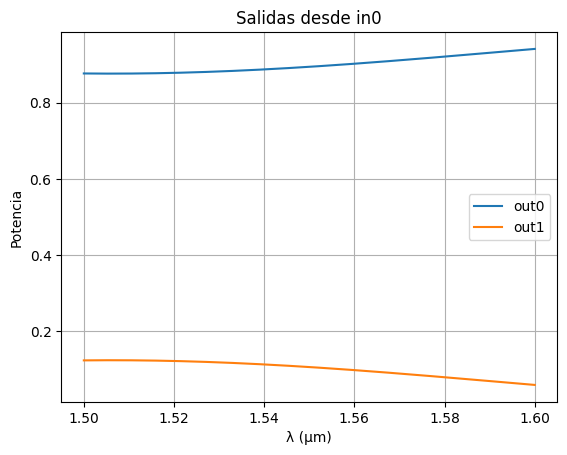

In [25]:
wl = np.linspace(1.50, 1.60, 2000)  # µm
S1_block = S1(wl=wl,
       c1 = {"coupling":0.5},
       c2 = {"coupling":0.17},
       c3 = {"coupling":0.23},
       c4 = {"coupling":0.05},

       w1_u = {"wl":wl, "neff":neff_TE0[0], "length": L1},
       w1_d = {"wl":wl, "neff":neff_TE0[0], "length": L2},

       w2_u = {"wl":wl, "neff":neff_TE0[0], "length": 2 * L2},
       w2_d = {"wl":wl, "neff":neff_TE0[0], "length": 2 * L1},

       w3_u = {"wl":wl, "neff":neff_TE0[0], "length": 2 * L2},
       w3_d = {"wl":wl, "neff":neff_TE0[0], "length": 2 * L1 + np.pi} ,
       )

S2_block = S2(wl=wl,
       c1 = {"coupling":0.5},
       c2 = {"coupling":0.3},
       c3 = {"coupling":0.05},

       w1_u = {"wl":wl, "neff":neff_TE0[0], "length": L1},
       w1_d = {"wl":wl, "neff":neff_TE0[0], "length": L2},

       w2_u = {"wl":wl, "neff":neff_TE0[0], "length": 2 * L2},
       w2_d = {"wl":wl, "neff":neff_TE0[0], "length": 2 * L1},
       )

plt.figure()

plt.plot(wl, np.abs(S1_block[('in1','out0')])**2, label="out0")
plt.plot(wl, np.abs(S1_block[('in1','out1')])**2, label="out1")

plt.xlabel("λ (µm)")
plt.ylabel("Potencia")
plt.title("Salidas desde in0")
plt.legend()
plt.grid()

plt.show()